In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

## 1. Load Data
Membaca file dataset `data.csv` yang berisi riwayat penjualan toko.

In [2]:
# Membaca dataset
df = pd.read_csv('data.csv')
df.head()

,ID_Transaksi,Tanggal,Nama_barang,Jumlah,Satuan
0,TRX-001,2026 - 5 - 18,Telor,0.5,Kg
1,TRX-001,2026 - 5 - 18,Bawang Merah,1.0,Ons
2,TRX-001,2026 - 5 - 18,Bawang Putih,0.5,Ons
3,TRX-002,2026 - 5 - 18,Rokok Jarum Super,1.0,Bungkus
4,TRX-002,2026 - 5 - 18,Chiki Balls,2.0,Bungkus


In [3]:
# 1. Bersihkan pemisah desimal koma menjadi titik pada kolom Jumlah
df['Jumlah'] = df['Jumlah'].astype(str).str.replace(',', '.').astype(float)

# 2. Standarisasi nama produk yang typo / duplikat
mapping_typo = {
    'Rokok Jarum Cokelat': 'Rokok Jarum Coklat',
    'Rokok Jarim Coklat': 'Rokok Jarum Coklat',
    'Jarum Super': 'Rokok Jarum Super',
    'Rokok Super': 'Rokok Jarum Super',
    'Rokok GGM': 'Rokok Garam Merah',
    'Garam': 'Rokok Garam Merah',
    'Gula Pasir Pasir': 'Gula Pasir',
}
df['Nama_barang'] = df['Nama_barang'].replace(mapping_typo)

df.loc[df['Satuan'] == 'Batang', 'Nama_barang'] = df.loc[df['Satuan'] == 'Batang', 'Nama_barang'] + ' (batang)'
df.head()

,ID_Transaksi,Tanggal,Nama_barang,Jumlah,Satuan
0,TRX-001,2026 - 5 - 18,Telor,0.5,Kg
1,TRX-001,2026 - 5 - 18,Bawang Merah,1.0,Ons
2,TRX-001,2026 - 5 - 18,Bawang Putih,0.5,Ons
3,TRX-002,2026 - 5 - 18,Rokok Jarum Super,1.0,Bungkus
4,TRX-002,2026 - 5 - 18,Chiki Balls,2.0,Bungkus


## 2. Preprocessing & Feature Engineering (Model Regresi)
Mengubah data transaksi mentah menjadi fitur input untuk model prediksi stok.

In [4]:
df_prep = df.copy()

df_prep['Jumlah'] = pd.to_numeric(df_prep['Jumlah'], errors='coerce').fillna(0.0) # Mengonversi kolom 'Jumlah' ke tipe numerik, menggantikan nilai yang tidak dapat dikonversi dengan 0.0

# Ekstraksi fitur tanggal
df_prep['tanggal'] = pd.to_datetime(df_prep['Tanggal'])
df_prep['tahun'] = df_prep['tanggal'].dt.year
df_prep['bulan'] = df_prep['tanggal'].dt.month
df_prep['hari'] = df_prep['tanggal'].dt.day

# Menentukan minggu ke berapa dalam bulan
df_prep['minggu_ke'] = ((df_prep['hari'] - 1) // 7) + 1
df_prep['minggu_ke'] = df_prep['minggu_ke'].clip(1, 5)

# Encoding nama barang menjadi ID numerik
unique_items = df_prep['Nama_barang'].unique()
item_to_id = {name: idx + 1 for idx, name in enumerate(unique_items)}
df_prep['barang_id'] = df_prep['Nama_barang'].map(item_to_id)

# Menambahkan kolom harga jual dengan nilai tetap (misalnya 5000)

dataset = df_prep.groupby(['tahun', 'bulan', 'minggu_ke', 'barang_id']).agg(
    jumlah_terjual=('Jumlah', 'sum')
).reset_index()

monthly_sales = df_prep.groupby(['tahun', 'bulan', 'barang_id'])['Jumlah'].sum().reset_index()
monthly_sales.rename(columns={'Jumlah': 'penjualan_bulan_lalu'}, inplace=True)

dataset['tahun_lalu'] = dataset['tahun']
dataset['bulan_lalu'] = dataset['bulan'] - 1

jan_mask = dataset['bulan'] == 1
dataset.loc[jan_mask, 'tahun_lalu'] = dataset['tahun'] - 1
dataset.loc[jan_mask, 'bulan_lalu'] = 12

dataset = pd.merge(
    dataset,
    monthly_sales,
    left_on=['tahun_lalu', 'bulan_lalu', 'barang_id'],
    right_on=['tahun', 'bulan', 'barang_id'],
    how='left',
    suffixes=('', '_temp')
)

dataset.drop(columns=['tahun_temp', 'bulan_temp', 'tahun_lalu', 'bulan_lalu'], errors='ignore', inplace=True)
dataset['penjualan_bulan_lalu'] = dataset['penjualan_bulan_lalu'].fillna(0)
dataset = dataset.sort_values(by=['tahun', 'bulan', 'minggu_ke', 'barang_id']).reset_index(drop=True)

features = ['barang_id', 'bulan', 'minggu_ke', 'penjualan_bulan_lalu']

print(f"Data berhasil dipreproses. Jumlah dataset teragregasi: {dataset.shape[0]} baris.")
print(f"Fitur input yang digunakan: {features}")
dataset.head()

Data berhasil dipreproses. Jumlah dataset teragregasi: 202 baris.
Fitur input yang digunakan: ['barang_id', 'bulan', 'minggu_ke', 'penjualan_bulan_lalu']


,tahun,bulan,minggu_ke,barang_id,jumlah_terjual,penjualan_bulan_lalu
0,2026,5,3,1,1.25,0.0
1,2026,5,3,2,1.00,0.0
2,2026,5,3,3,1.50,0.0
3,2026,5,3,4,8.00,0.0
4,2026,5,3,5,3.00,0.0


## 3. Pembangunan Pipeline & Evaluasi Model
Membangun pipeline model ML dan mengevaluasi performa menggunakan 5-Fold Cross Validation.

In [5]:
X = dataset[features].values
y = dataset['jumlah_terjual'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', DecisionTreeRegressor(max_depth=3, min_samples_split=20, random_state=42))
    ])
    
    pipeline.fit(X_tr, y_tr)
    
    preds = pipeline.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    mae_scores.append(mae)
    print(f"Fold {fold} - MAE: {mae:.4f} unit laku")

mean_mae = np.mean(mae_scores)
print(f"\nRata-rata MAE Keseluruhan: {mean_mae:.4f} unit laku")

Fold 1 - MAE: 5.1954 unit laku
Fold 2 - MAE: 2.7208 unit laku
Fold 3 - MAE: 1.6160 unit laku
Fold 4 - MAE: 4.1994 unit laku
Fold 5 - MAE: 3.7858 unit laku

Rata-rata MAE Keseluruhan: 3.5035 unit laku


## 4. Final Model Training & Visualisasi
Melatih pipeline model pada seluruh data yang tersedia dan melakukan visualisasi pohon keputusan (*decision tree*).

Model Pipeline akhir berhasil dilatih pada seluruh data.


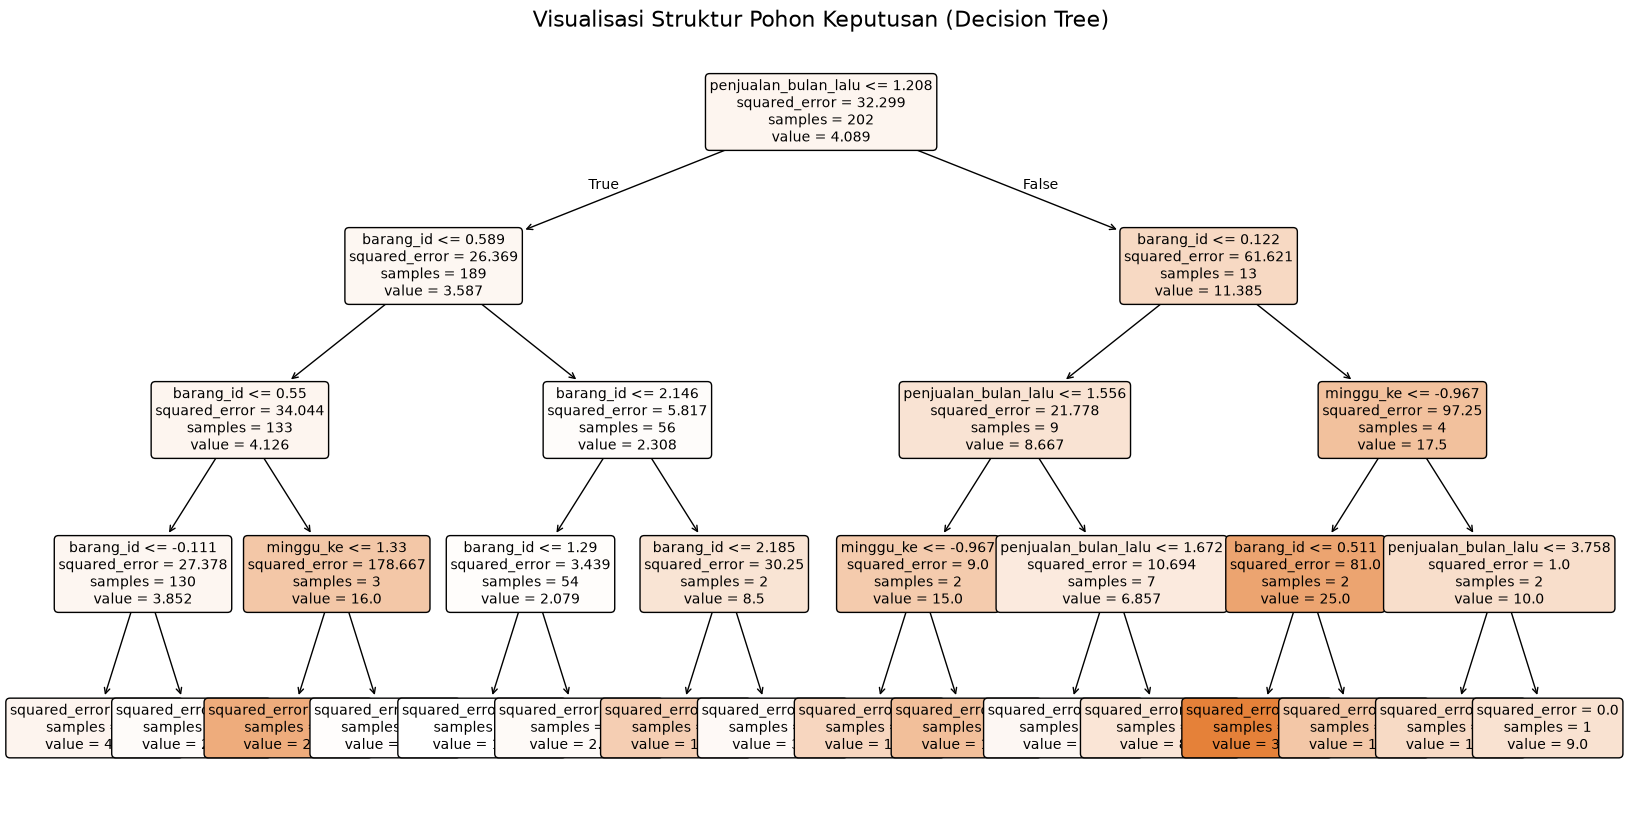

In [6]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(max_depth=3, min_samples_split=20, random_state=42))
])
final_pipeline.fit(X, y)

print("Model Pipeline akhir berhasil dilatih pada seluruh data.")

regressor_model = final_pipeline.named_steps['regressor']
plt.figure(figsize=(20, 10))
plot_tree(
    regressor_model, 
    feature_names=features, 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Visualisasi Struktur Pohon Keputusan (Decision Tree)", fontsize=16)
plt.show()

## 5. Simpan Pipeline ke File `.joblib`
Menyimpan objek pipeline terlatih beserta daftar fitur dan skor evaluasi menggunakan format `.joblib`

In [7]:
model_save_path = 'model.joblib'

model_data = {
    "pipeline": final_pipeline,
    "features": features,
    "mean_mae": mean_mae,
    "data_count": len(dataset)
}

joblib.dump(model_data, model_save_path)
print(f"Sukses! Model Pipeline berhasil disimpan di: {model_save_path}")

Sukses! Model Pipeline berhasil disimpan di: model.joblib


## 6. Analisis Asosiasi (Apriori)
Menggunakan algoritma **Apriori** dari library **`mlxtend`** untuk menganalisis keterkaitan antar produk dalam transaksi (Market Basket Analysis).

In [8]:
transactions_df = df.groupby('ID_Transaksi')['Nama_barang'].apply(list).reset_index()
transactions = transactions_df['Nama_barang'].tolist()

print(f"Total transaksi kasir terdeteksi: {len(transactions)} keranjang.")
print("Contoh 5 keranjang transaksi pertama:")
for i, t in enumerate(transactions[:5], 1):
    print(f"  Keranjang {i}: {t}")

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nDimensi matriks biner transaksi: {df_encoded.shape[0]} baris x {df_encoded.shape[1]} produk.")
df_encoded.head()

Total transaksi kasir terdeteksi: 292 keranjang.
Contoh 5 keranjang transaksi pertama:
  Keranjang 1: ['Telor', 'Bawang Merah', 'Bawang Putih']
  Keranjang 2: ['Rokok Jarum Super', 'Chiki Balls']
  Keranjang 3: ['Choki Choki']
  Keranjang 4: ['Air mineral', 'Permen']
  Keranjang 5: ['Teh pucuk']

Dimensi matriks biner transaksi: 292 baris x 95 produk.


,Aida,Air Mineral,Air mineral,Amplop,Baterai,Baterai ABC,Bawang,Bawang Merah,Bawang Putih,Beng-Beng,...,Telur,Tembakau Jangkar,Tepung Serbaguna,Tepung Tapioka,Tepung Tepung Terigu,Tepung Terigu,Terasi,Tisu,Tolak Angin,Wafer Super Star
0,False,False,False,False,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
min_support = 0.02
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

frequent_itemsets['Itemset Size'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets['Frequency'] = (frequent_itemsets['support'] * len(df_encoded)).round(0)

frequent_itemsets_display = frequent_itemsets[frequent_itemsets['Itemset Size'] >= 2].copy()
frequent_itemsets_display = frequent_itemsets_display[['support', 'itemsets', 'Itemset Size', 'Frequency']]
frequent_itemsets_display.columns = ['Support', 'Itemsets', 'Itemset Size', 'Frequency']

print(f"Berhasil menemukan {len(frequent_itemsets)} frequent itemsets total (tunggal + kombinasi).")
print(f"Jumlah kombinasi itemset (jumlah barang >= 2): {len(frequent_itemsets_display)}.")

frequent_itemsets_display.head(10)

Berhasil menemukan 26 frequent itemsets total (tunggal + kombinasi).
Jumlah kombinasi itemset (jumlah barang >= 2): 5.


,Support,Itemsets,Itemset Size,Frequency
21,0.023973,"frozenset({Minyak Goreng Curah, Masako})",2,7.0
22,0.020548,"frozenset({Tepung Tapioka, Masako})",2,6.0
23,0.023973,"frozenset({Tepung Tapioka, Minyak Goreng Curah})",2,7.0
24,0.030822,"frozenset({Tepung Terigu, Minyak Goreng Curah})",2,9.0
25,0.020548,"frozenset({Tepung Tapioka, Minyak Goreng Curah...",3,6.0


In [10]:
min_confidence = 0.3
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

rules['Rule'] = rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' + rules['consequents'].apply(lambda x: ', '.join(list(x)))

rules_display = rules.sort_values(by=['confidence', 'lift'], ascending=[False, False]).reset_index(drop=True)

rules_display = rules_display[['Rule', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift']]
rules_display.columns = ['Rule', 'Antecedent Support', 'Consequent Support', 'Support', 'Confidence', 'Lift']

print(f"Berhasil menghasilkan {len(rules_display)} aturan asosiasi.")

rules_display.head(10)

Berhasil menghasilkan 10 aturan asosiasi.


,Rule,Antecedent Support,Consequent Support,Support,Confidence,Lift
0,"Tepung Tapioka, Masako -> Minyak Goreng Curah",0.020548,0.133562,0.020548,1.000000,7.487179
1,Masako -> Minyak Goreng Curah,0.027397,0.133562,0.023973,0.875000,6.551282
2,"Tepung Tapioka, Minyak Goreng Curah -> Masako",0.023973,0.027397,0.020548,0.857143,31.285714
3,"Minyak Goreng Curah, Masako -> Tepung Tapioka",0.023973,0.034247,0.020548,0.857143,25.028571
4,"Masako -> Tepung Tapioka, Minyak Goreng Curah",0.027397,0.023973,0.020548,0.750000,31.285714
5,Masako -> Tepung Tapioka,0.027397,0.034247,0.020548,0.750000,21.900000
6,Tepung Tapioka -> Minyak Goreng Curah,0.034247,0.133562,0.023973,0.700000,5.241026
7,"Tepung Tapioka -> Minyak Goreng Curah, Masako",0.034247,0.023973,0.020548,0.600000,25.028571
8,Tepung Tapioka -> Masako,0.034247,0.027397,0.020548,0.600000,21.900000
9,Tepung Terigu -> Minyak Goreng Curah,0.065068,0.133562,0.030822,0.473684,3.546559
